In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.transform import Rotation

csv_dir = Path("csvs")
csv_files = sorted(csv_dir.glob("*.csv"))


In [4]:
# ---- EDIT THIS LIST ----
CSV_NAMES = [
    "l1.csv",
    "l2.csv",
    "l3.csv",
    "l4.csv",
    "l5.csv",
    "s1.csv",
    "s2.csv",
    "s3.csv",
    "s4.csv",
    "s5.csv",

]
# -------------------------

csv_dir = Path("csvs")
bags = {}
for name in CSV_NAMES:
    f = csv_dir / f"{name}.csv"
    if not f.exists():
        print(f"[WARN] {f} not found, skipping")
        continue
    df = pd.read_csv(f)
    df["time"] = df["timestamp_sec"] + df["timestamp_nanosec"] * 1e-9
    df["time"] -= df["time"].iloc[0]
    quats = df[["orient_x", "orient_y", "orient_z", "orient_w"]].values
    df["yaw"] = Rotation.from_quat(quats).as_euler("xyz")[:, 2]
    bags[name] = df

print(f"Loaded {len(bags)}/{len(CSV_NAMES)} bag(s)")

[WARN] csvs/l1.csv.csv not found, skipping
[WARN] csvs/l2.csv.csv not found, skipping
[WARN] csvs/l3.csv.csv not found, skipping
[WARN] csvs/l4.csv.csv not found, skipping
[WARN] csvs/l5.csv.csv not found, skipping
[WARN] csvs/s1.csv.csv not found, skipping
[WARN] csvs/s2.csv.csv not found, skipping
[WARN] csvs/s3.csv.csv not found, skipping
[WARN] csvs/s4.csv.csv not found, skipping
[WARN] csvs/s5.csv.csv not found, skipping
Loaded 0/10 bag(s)


In [37]:
def plot_bag(name, title=None):
    df = pd.read_csv(Path("csvs") / f"{name}.csv")
    df["time"] = df["timestamp_sec"] + df["timestamp_nanosec"] * 1e-9
    df["time"] -= df["time"].iloc[0]
    quats = df[["orient_x", "orient_y", "orient_z", "orient_w"]].values
    df["yaw"] = Rotation.from_quat(quats).as_euler("xyz")[:, 2]

    display_title = title if title else name

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].plot(df["pos_x"], df["pos_y"], linewidth=1.5)
    axes[0].scatter(df["pos_x"].iloc[0], df["pos_y"].iloc[0], marker="o", s=80, c="green", label="start", zorder=5)
    axes[0].scatter(df["pos_x"].iloc[-1], df["pos_y"].iloc[-1], marker="x", s=80, c="red", label="end", zorder=5)
    axes[0].set_xlabel("x (m)")
    axes[0].set_ylabel("y (m)")
    axes[0].set_title("Path (x vs y)")
    axes[0].set_aspect("equal")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    ax_x = axes[1]
    ax_y = ax_x.twinx()
    ax_x.plot(df["time"], df["pos_x"], label="x", color="tab:blue")
    ax_x.plot(df["time"], df["pos_y"], label="y", color="tab:orange")
    ax_x.set_xlabel("time (s)")
    ax_x.set_ylabel("position (m)")
    ax_y.plot(df["time"], np.degrees(df["yaw"]), label="yaw", color="tab:green", alpha=0.7)
    ax_y.set_ylabel("yaw (°)")
    ax_x.legend(loc="upper left")
    ax_y.legend(loc="upper right")
    axes[1].set_title("Position & Heading over Time")
    ax_x.grid(True, alpha=0.3)

    fig.suptitle(display_title, fontsize=14)
    plt.tight_layout()
    plt.show()

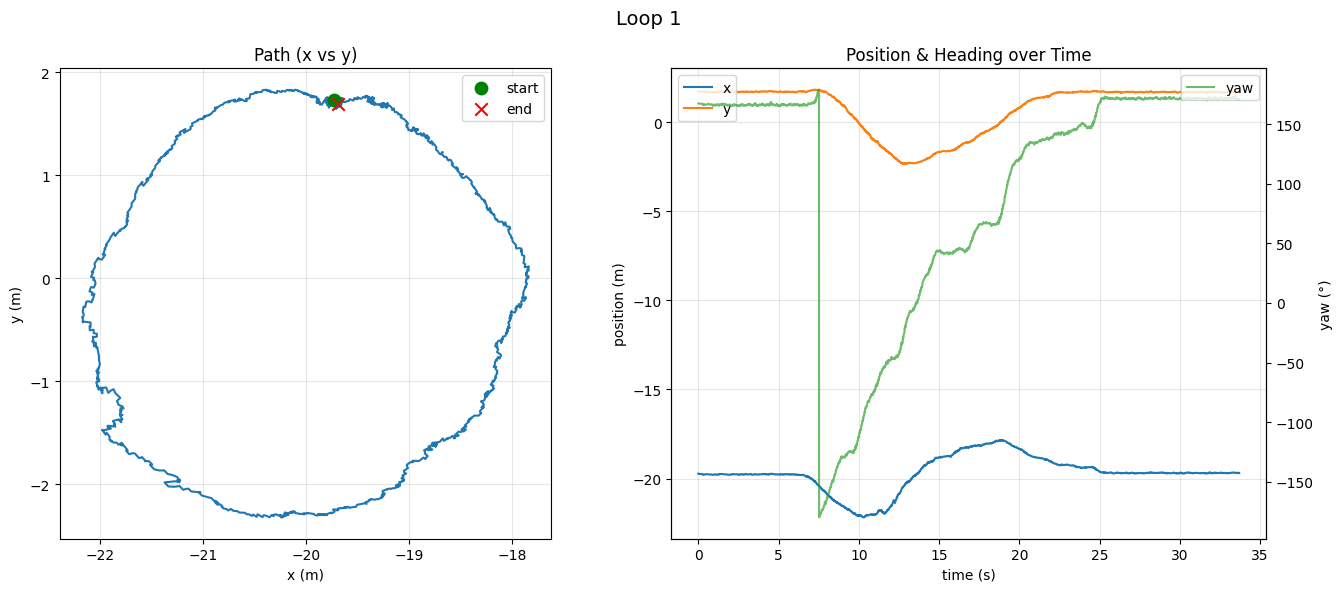

In [38]:
plot_bag("l1", title="Loop 1")


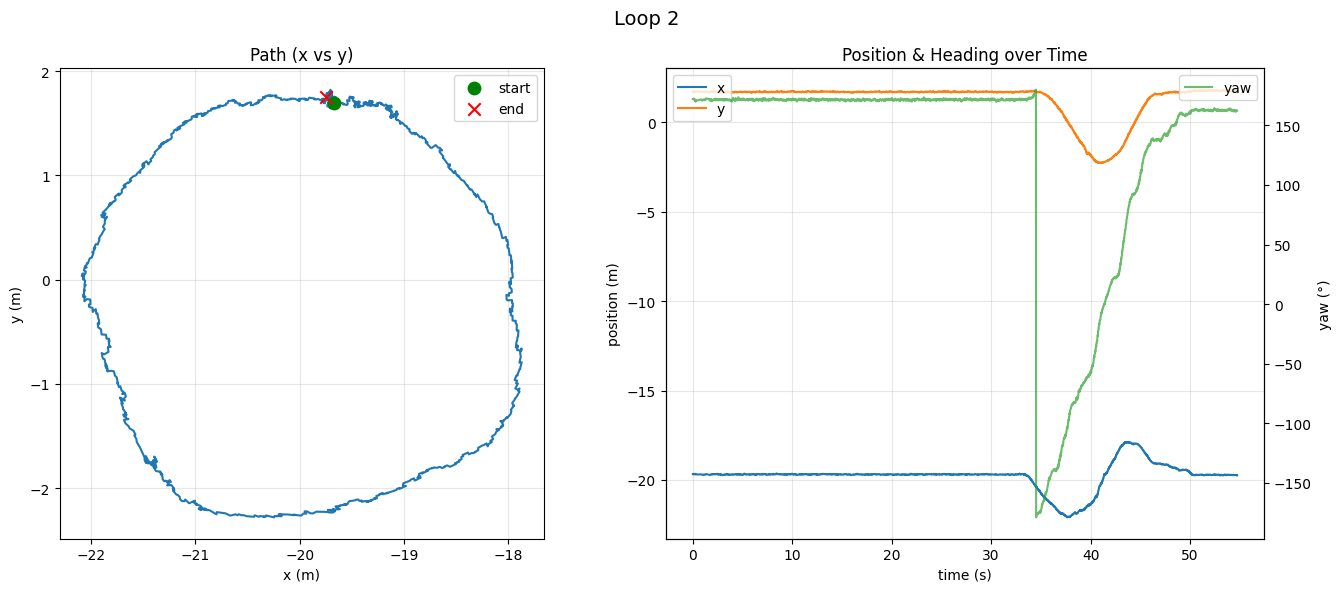

In [39]:
plot_bag("l2", title="Loop 2")

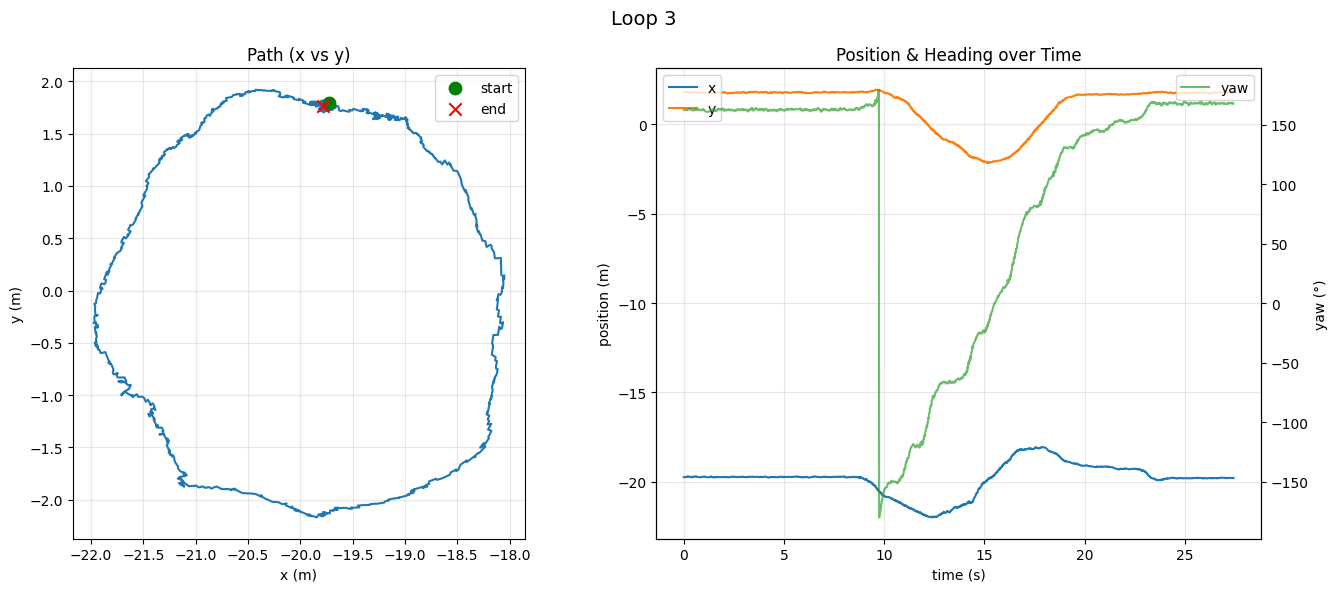

In [40]:
plot_bag("l3", title="Loop 3")

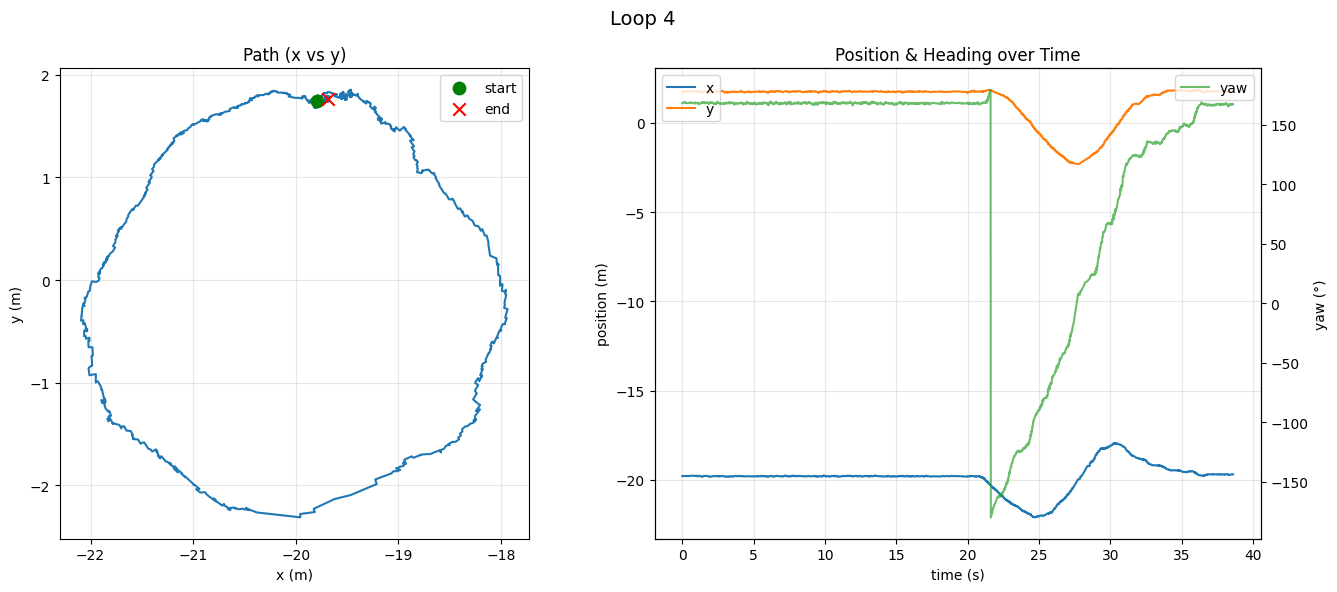

In [41]:
plot_bag("l4", title="Loop 4")

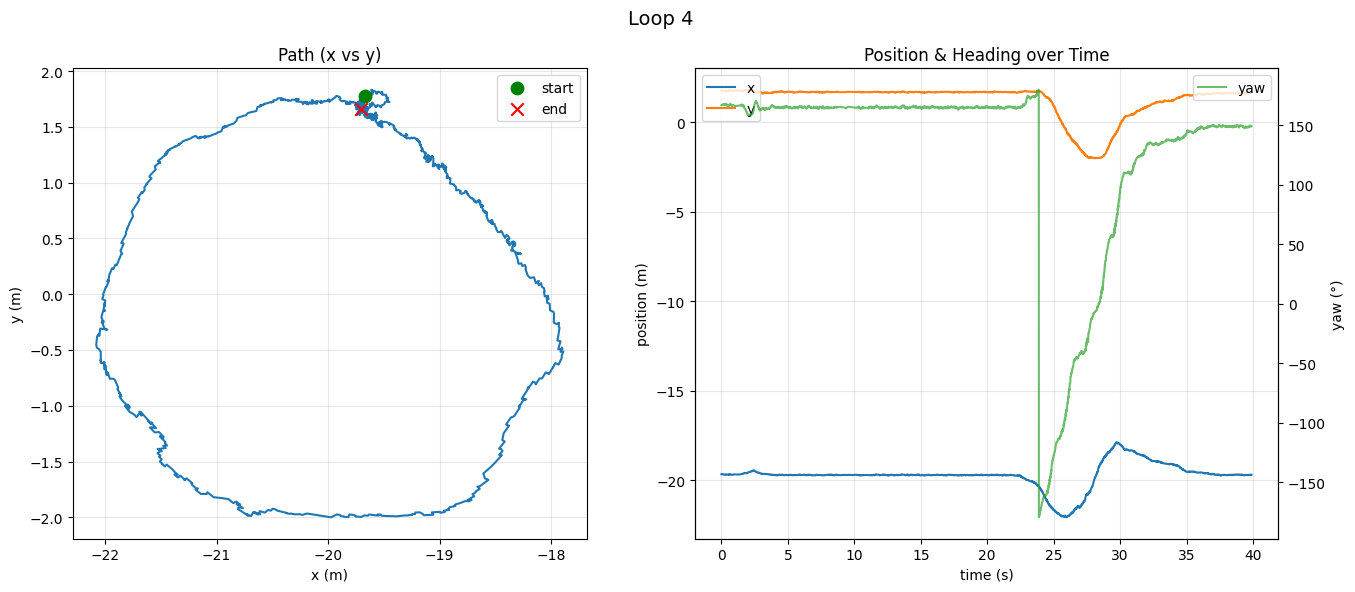

In [42]:
plot_bag("l5", title="Loop 4")

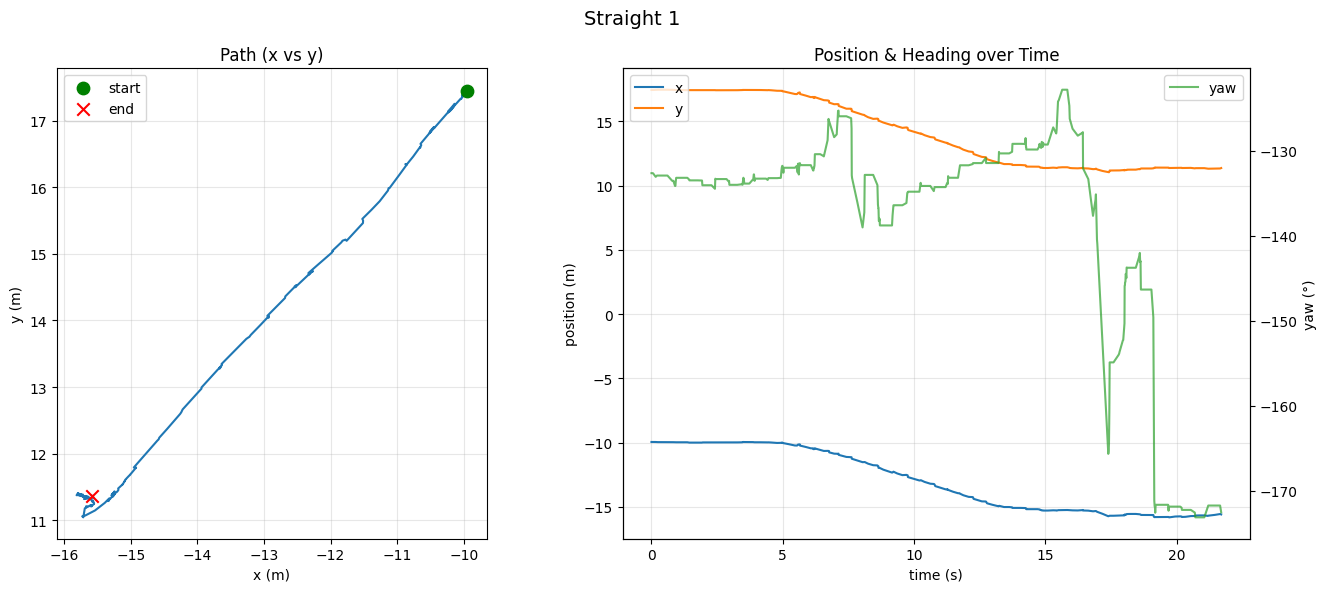

In [43]:
plot_bag("s1", title="Straight 1")


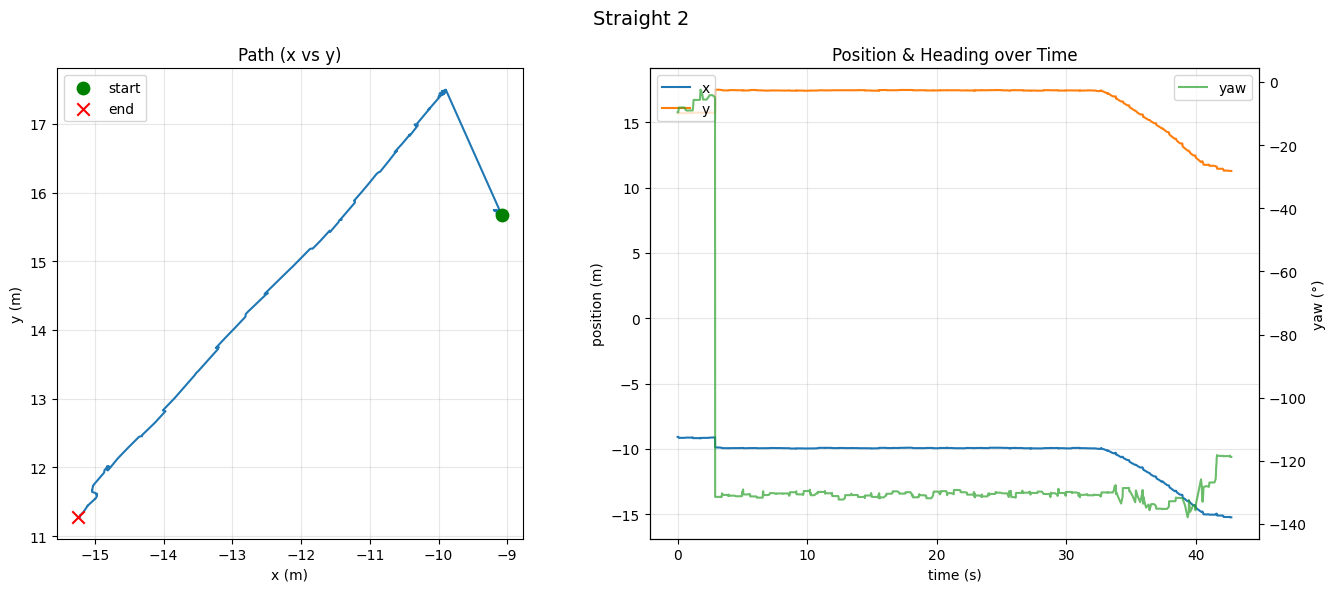

In [44]:
plot_bag("s2", title="Straight 2")


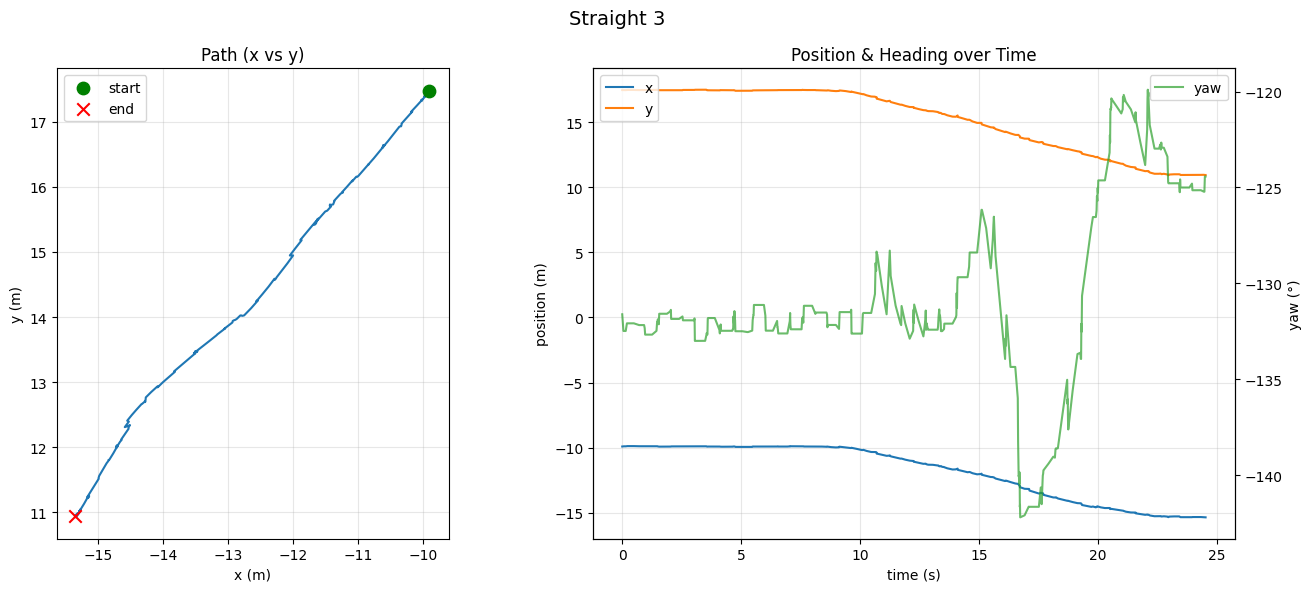

In [45]:
plot_bag("s3", title="Straight 3")

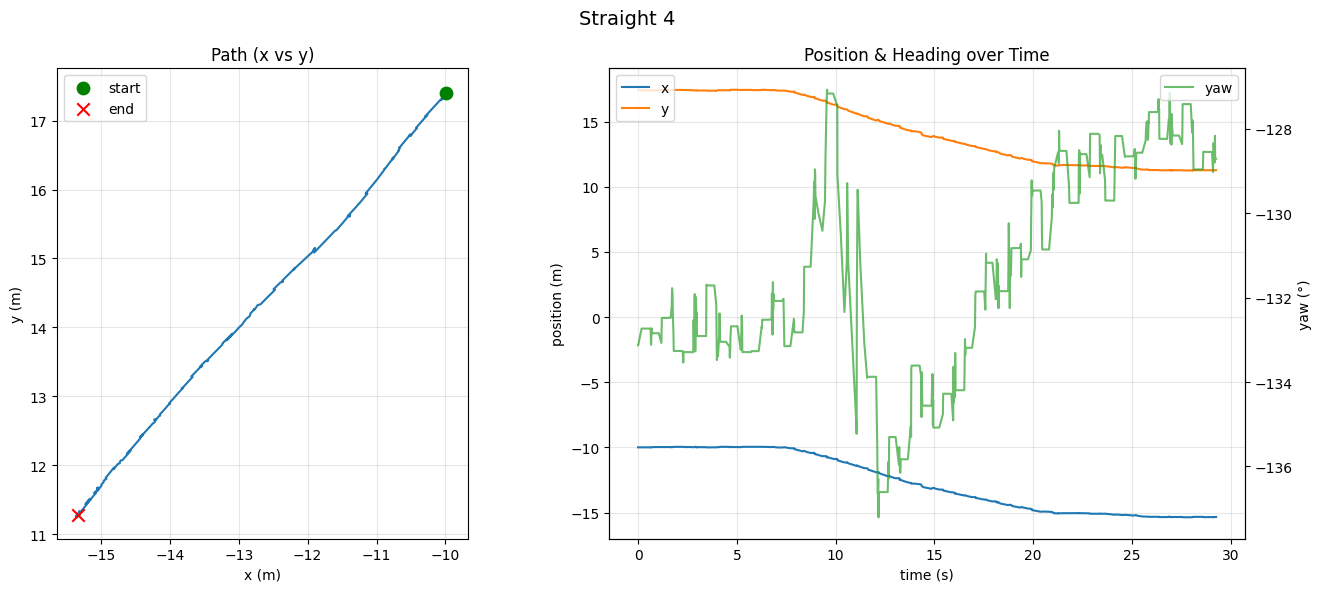

In [46]:
plot_bag("s4", title="Straight 4")

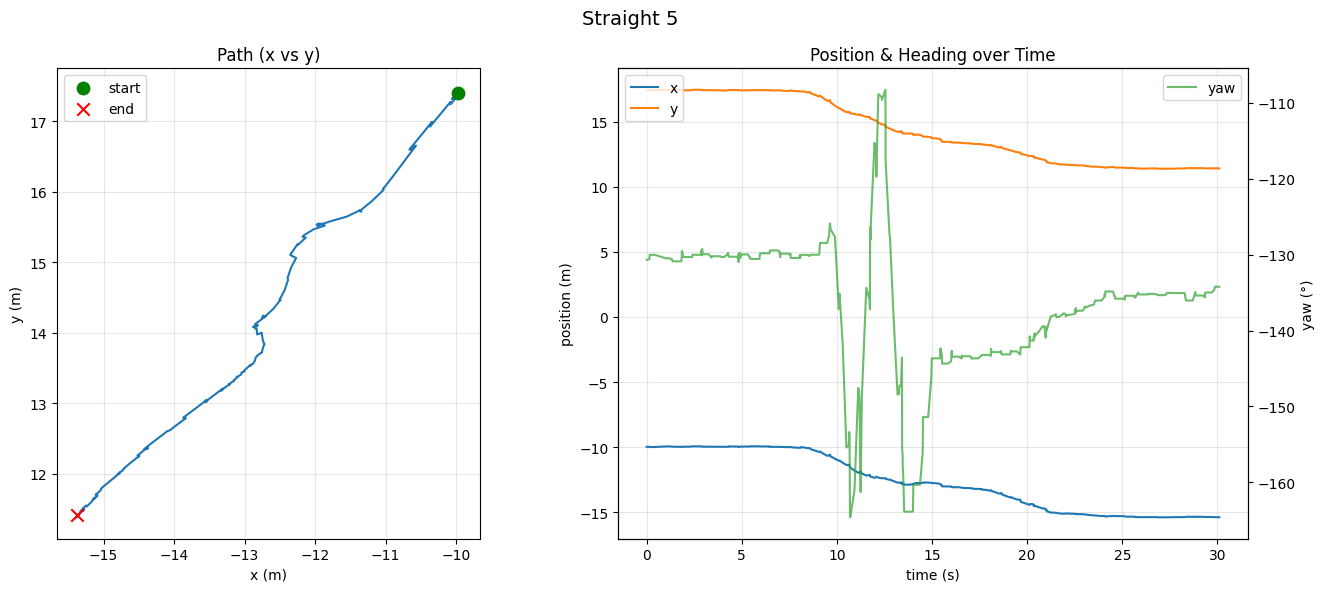

In [47]:
plot_bag("s5", title="Straight 5")